# Heart Disease Risk Stratification - Exploratory Data Analysis (EDA)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")


## 2. Load Dataset

In [2]:
df = pd.read_csv('../data/heart.csv')
display(df.head())
print(df.info())


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB
None


## 3. Data Inspection & Cleaning

In [3]:
# Target Variable might have values 0, 1, 2, 3, 4 where >0 means presence of heart disease.
# We will convert this into a binary classification problem: 0 = No Heart Disease, 1 = Heart Disease
if df['target'].max() > 1:
    df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# The UCI dataset has '?' for missing values in 'ca' and 'thal' occasionally, if imported directly.
# Let's check for any missing values or '?'
df.replace('?', np.nan, inplace=True)
print("Missing values per column:\n", df.isnull().sum())

# We will save this for preprocessing step, for now just drop them to do EDA
df_eda = df.dropna()


Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


## 4. Exploratory Data Analysis

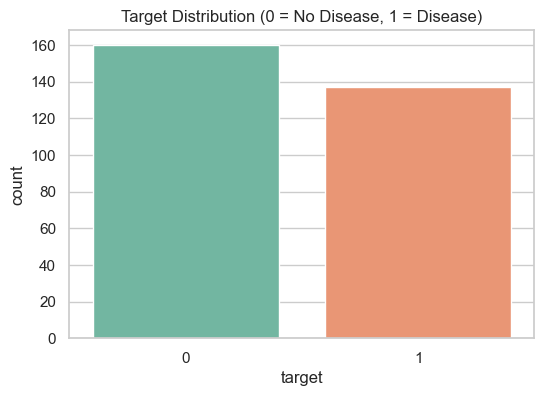

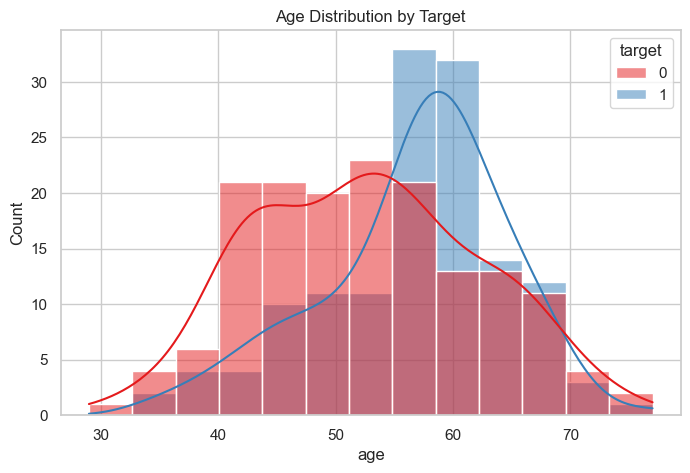

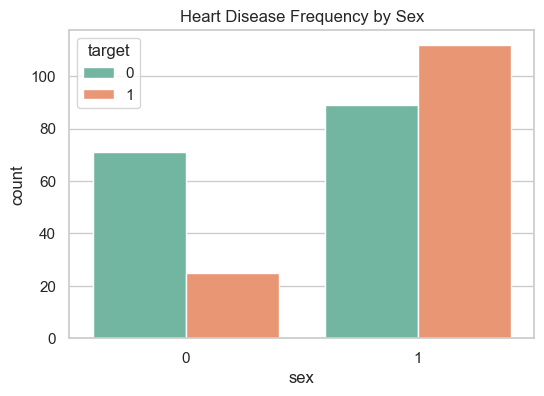

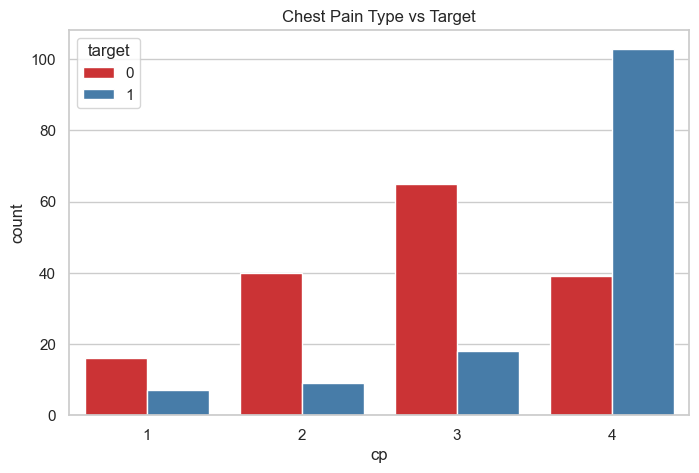

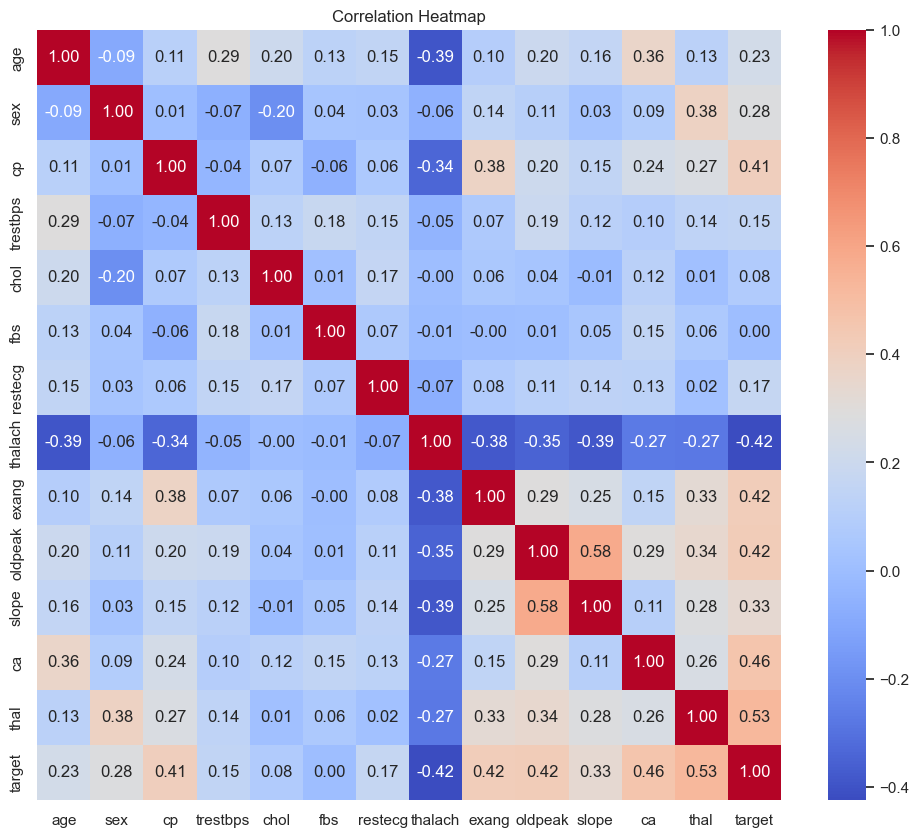

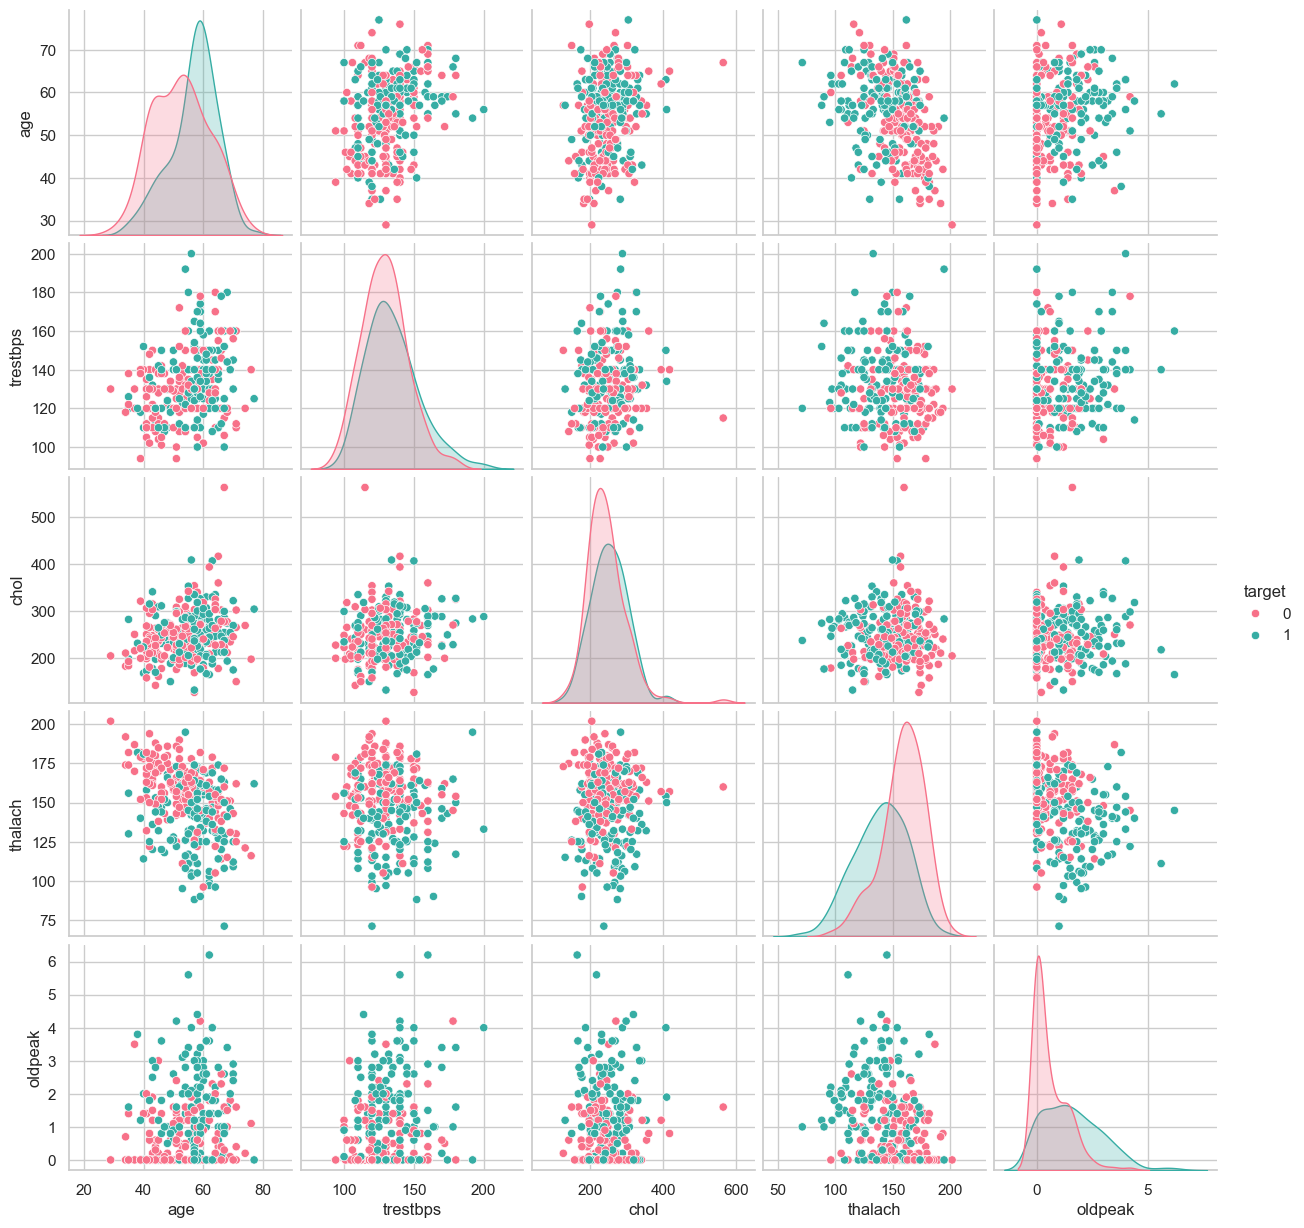

In [4]:
# 1. Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df_eda, x='target', palette='Set2')
plt.title('Target Distribution (0 = No Disease, 1 = Disease)')
plt.show()

# 2. Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df_eda, x='age', hue='target', kde=True, palette='Set1')
plt.title('Age Distribution by Target')
plt.show()

# 3. Sex and Heart Disease (0 = Female, 1 = Male)
plt.figure(figsize=(6,4))
sns.countplot(data=df_eda, x='sex', hue='target', palette='Set2')
plt.title('Heart Disease Frequency by Sex')
plt.show()

# 4. Chest Pain Type vs Target
plt.figure(figsize=(8,5))
sns.countplot(data=df_eda, x='cp', hue='target', palette='Set1')
plt.title('Chest Pain Type vs Target')
plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(12,10))
# convert object types to numeric if any for correlation
corr_df = df_eda.apply(pd.to_numeric)
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 6. Pairplot for continuous variables
cont_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']
sns.pairplot(corr_df[cont_vars], hue='target', palette='husl')
plt.show()
